In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from xgboost import XGBClassifier, plot_importance

pd.set_option("display.max_columns", 120)


In [ ]:
# Run this cell only on Google Colab.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#%cd "/content/drive/MyDrive/Final Assignment "
%cd "/content/drive/MyDrive/Final Assignment /Final Assignment"

/content/drive/.shortcut-targets-by-id/1UxmN3o99Ed5r3IwnMVVcT7fi0h4slOvc/05. Final Assignment (due Jun 19th 11AM UTC)/Final Assignment


In [ ]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /content/drive/.shortcut-targets-by-id/1UxmN3o99Ed5r3IwnMVVcT7fi0h4slOvc/05. Final Assignment (due Jun 19th 11AM UTC)/Final Assignment/telecom/Client.csv
OK  /content/drive/.shortcut-targets-by-id/1UxmN3o99Ed5r3IwnMVVcT7fi0h4slOvc/05. Final Assignment (due Jun 19th 11AM UTC)/Final Assignment/telecom/Record.csv


In [ ]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


In [ ]:
common_cols = set(client.columns).intersection(set(record.columns))

print(common_cols)

{'Customer_ID'}


In [ ]:
record.head()

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005


In [ ]:
client.head()

,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0,1000005


In [ ]:
print("CLIENT COLUMNS")
print(client.columns.tolist())

print("\n\nRECORD COLUMNS")
print(record.columns.tolist())

CLIENT COLUMNS
['uniqsubs', 'actvsubs', 'new_cell', 'crclscod', 'asl_flag', 'totcalls', 'totmou', 'totrev', 'adjrev', 'adjmou', 'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_price', 'phones', 'models', 'hnd_webcap', 'truck', 'rv', 'ownrent', 'lor', 'dwlltype', 'marital', 'adults', 'infobase', 'income', 'numbcars', 'HHstatin', 'dwllsize', 'forgntvl', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd', 'eqpdays', 'Customer_ID']


RECORD COLUMNS
['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean', 'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean', 'comp_dat_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean', 'ino

In [ ]:
df = client.merge(
    record,
    on='Customer_ID',
    how='inner'
)

print(df.shape)

(100000, 100)


In [ ]:
df['churn'].value_counts()

,count
churn,
0,50438
1,49562


In [ ]:
df['churn'].value_counts(normalize=True) * 100

,proportion
churn,
0,50.438
1,49.562


In [ ]:
print(df.shape)

(100000, 100)


In [ ]:
df['churn'].value_counts()

,count
churn,
0,50438
1,49562


In [ ]:
df['churn'].value_counts(normalize=True) * 100

,proportion
churn,
0,50.438
1,49.562


In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

churn_means = (
    df.groupby('churn')[numerical_cols]
      .mean()
      .T
)

churn_means['difference'] = (
    churn_means[1] - churn_means[0]
)

churn_means = churn_means.sort_values(
    by='difference',
    key=abs,
    ascending=False
)

churn_means.head(30)

churn,0,1,difference
Customer_ID,1.051224e+06,1.048755e+06,-2469.097153
adjmou,7.695686e+03,7.394304e+03,-301.381752
totmou,7.793975e+03,7.500179e+03,-293.796661
adjqty,2.896912e+03,2.774752e+03,-122.159346
totcalls,2.936440e+03,2.816796e+03,-119.643435
mou_Mean,5.432069e+02,4.833064e+02,-59.900478
eqpdays,3.632809e+02,4.210895e+02,57.808600
avg3mou,5.458501e+02,4.929691e+02,-52.880964
avg6mou,5.314451e+02,4.876795e+02,-43.765657
mou_cvce_Mean,2.414035e+02,2.138825e+02,-27.520948


In [ ]:
churn_means.head(30)

churn,0,1,difference
Customer_ID,1.051224e+06,1.048755e+06,-2469.097153
adjmou,7.695686e+03,7.394304e+03,-301.381752
totmou,7.793975e+03,7.500179e+03,-293.796661
adjqty,2.896912e+03,2.774752e+03,-122.159346
totcalls,2.936440e+03,2.816796e+03,-119.643435
mou_Mean,5.432069e+02,4.833064e+02,-59.900478
eqpdays,3.632809e+02,4.210895e+02,57.808600
avg3mou,5.458501e+02,4.929691e+02,-52.880964
avg6mou,5.314451e+02,4.876795e+02,-43.765657
mou_cvce_Mean,2.414035e+02,2.138825e+02,-27.520948


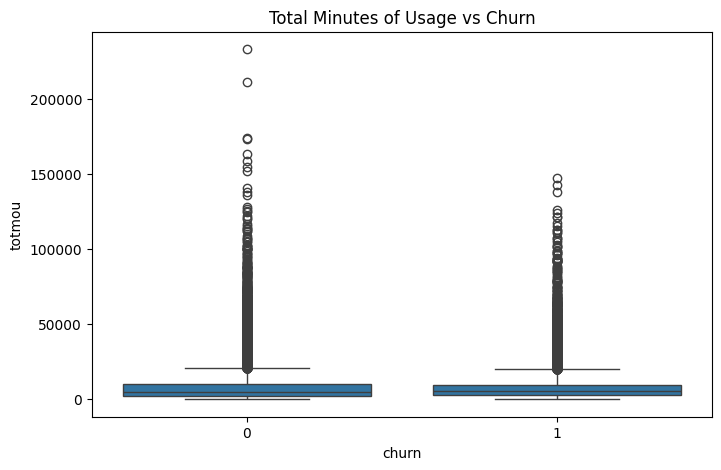

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='churn',
    y='totmou'
)

plt.title("Total Minutes of Usage vs Churn")
plt.show()

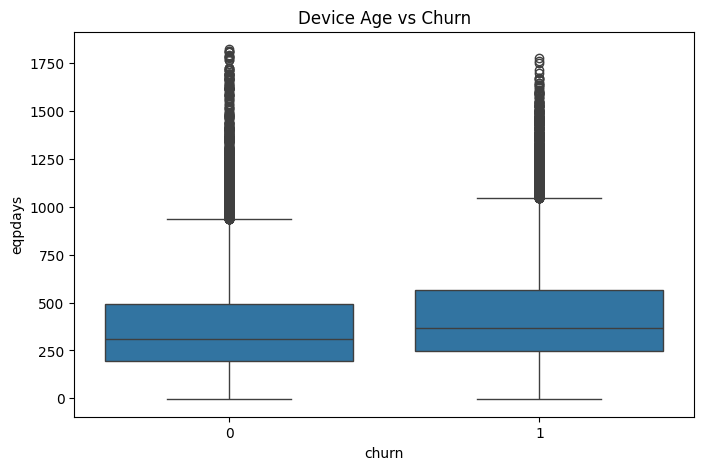

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='churn',
    y='eqpdays'
)

plt.title("Device Age vs Churn")
plt.show()

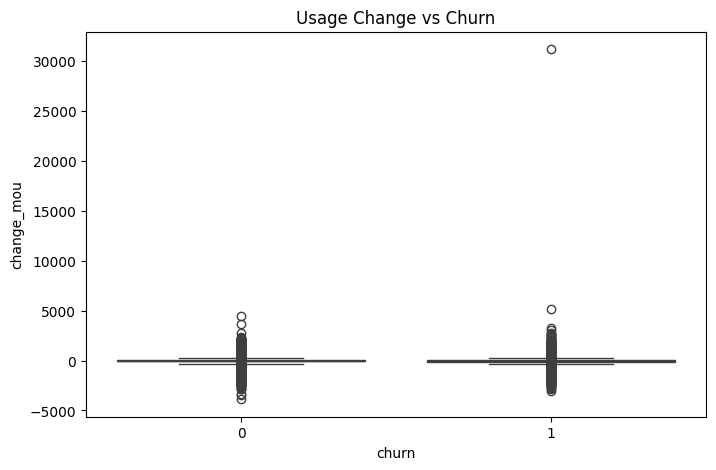

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='churn',
    y='change_mou'
)

plt.title("Usage Change vs Churn")
plt.show()

In [ ]:
df.groupby('churn')['totrev'].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,50438.0,1034.475849,908.759250,3.65,494.0900,784.400,1268.1600,27321.50
1,49562.0,1029.329041,792.036166,13.70,547.1775,823.655,1259.1475,16715.21


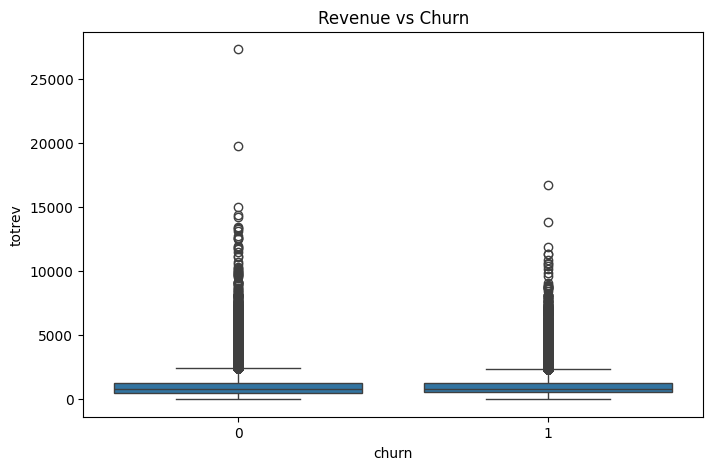

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='churn',
    y='totrev'
)

plt.title("Revenue vs Churn")
plt.show()

In [ ]:
network_cols = [
    'drop_vce_Mean',
    'blck_vce_Mean',
    'unan_vce_Mean',
    'drop_blk_Mean'
]

df.groupby('churn')[network_cols].mean().T

churn,0,1
drop_vce_Mean,6.090553,5.817222
blck_vce_Mean,4.118370,3.925776
unan_vce_Mean,29.137046,26.408865
drop_blk_Mean,10.286563,9.797752


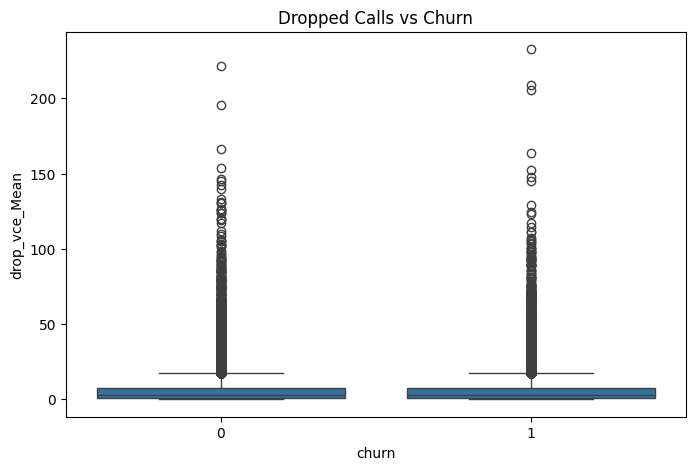

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='churn',
    y='drop_vce_Mean'
)

plt.title("Dropped Calls vs Churn")
plt.show()

In [ ]:
df['device_age_group'] = pd.cut(
    df['eqpdays'],
    bins=[-1,180,365,730,5000],
    labels=[
        '0-6 Months',
        '6-12 Months',
        '1-2 Years',
        '2+ Years'
    ]
)

In [ ]:
device_churn = (
    df.groupby('device_age_group')['churn']
      .mean()
      .sort_index()
      * 100
)

device_churn

/tmp/ipykernel_4922/2304652382.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('device_age_group')['churn']


,churn
device_age_group,
0-6 Months,41.783005
6-12 Months,46.971614
1-2 Years,53.838574
2+ Years,57.894737


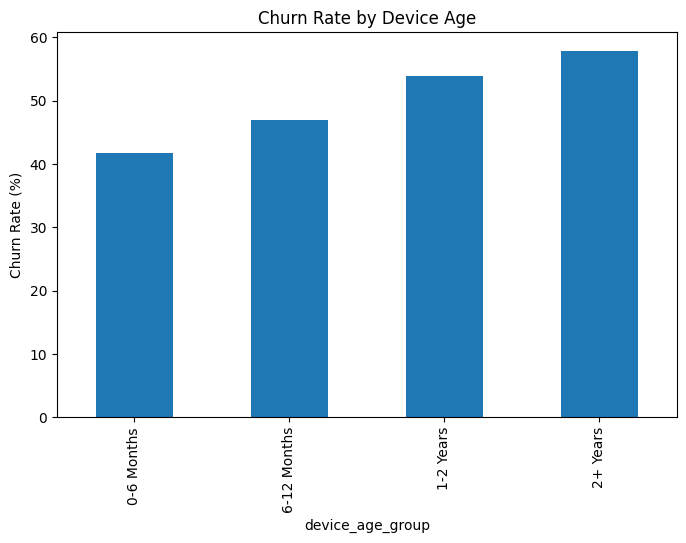

In [ ]:
device_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Churn Rate by Device Age")
plt.ylabel("Churn Rate (%)")
plt.show()

In [ ]:
tenure_churn = (
    pd.qcut(df['months'], q=4)
)

df.groupby(tenure_churn)['churn'].mean() * 100

/tmp/ipykernel_4922/820495763.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(tenure_churn)['churn'].mean() * 100


,churn
months,
"(5.999, 11.0]",43.332071
"(11.0, 16.0]",55.443370
"(16.0, 24.0]",50.753072
"(24.0, 61.0]",49.370165


/tmp/ipykernel_4922/2048383070.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(tenure_churn)['churn'].mean().plot(


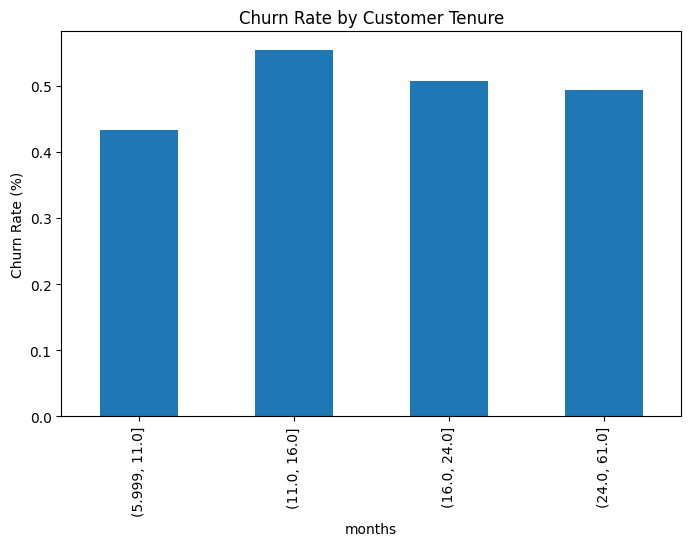

In [ ]:
df.groupby(tenure_churn)['churn'].mean().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Churn Rate by Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.show()

In [ ]:
device_segment = (
    df.groupby('device_age_group')
      .agg(
          customers=('churn','count'),
          churn_rate=('churn','mean'),
          avg_revenue=('totrev','mean'),
          avg_usage=('totmou','mean')
      )
)

device_segment['churn_rate'] = (
    device_segment['churn_rate'] * 100
)

device_segment.round(2)

/tmp/ipykernel_4922/3860587397.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('device_age_group')


,customers,churn_rate,avg_revenue,avg_usage
device_age_group,,,,
0-6 Months,18194,41.78,1294.19,11256.00
6-12 Months,36356,46.97,824.15,6687.55
1-2 Years,34505,53.84,1033.48,7096.88
2+ Years,10811,57.89,1277.04,6468.97


In [ ]:
device_segment = (
    df.groupby('device_age_group')
      .agg(
          customers=('churn','count'),
          churn_rate=('churn','mean'),
          avg_revenue=('totrev','mean'),
          avg_usage=('totmou','mean')
      )
)

device_segment['churn_rate'] *= 100

device_segment.round(2)

/tmp/ipykernel_4922/968284561.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('device_age_group')


,customers,churn_rate,avg_revenue,avg_usage
device_age_group,,,,
0-6 Months,18194,41.78,1294.19,11256.00
6-12 Months,36356,46.97,824.15,6687.55
1-2 Years,34505,53.84,1033.48,7096.88
2+ Years,10811,57.89,1277.04,6468.97


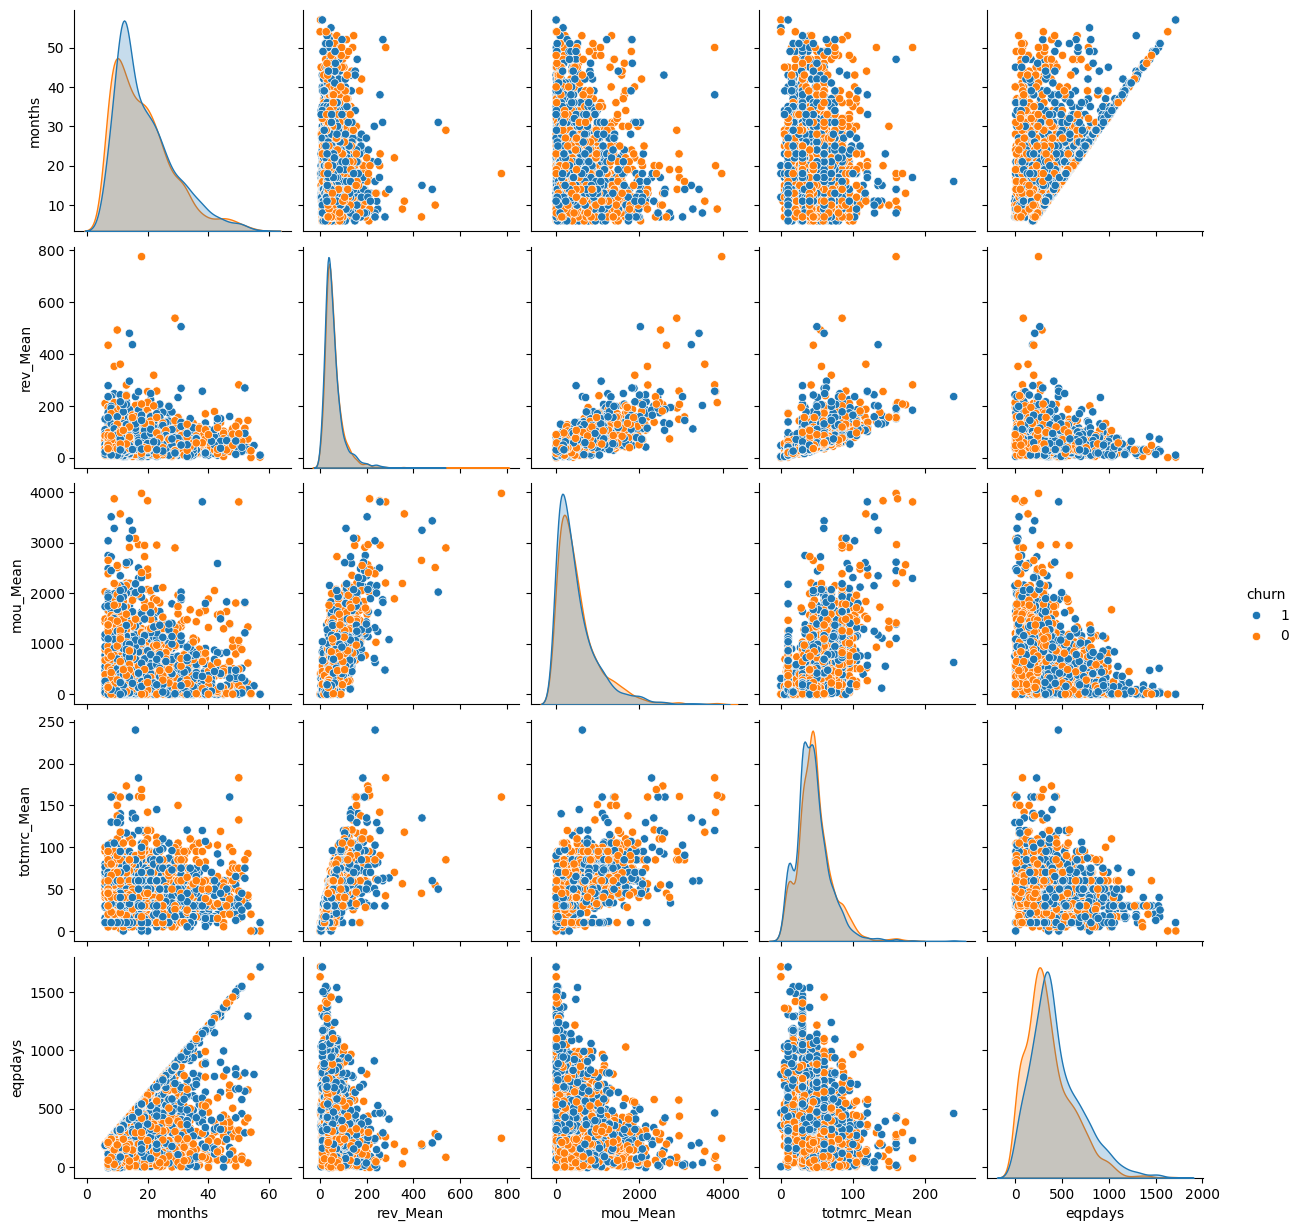

In [ ]:
plot_df = df[[
    'months',
    'rev_Mean',
    'mou_Mean',
    'totmrc_Mean',
    'eqpdays',
    'churn'
]].dropna().copy()

plot_df['churn'] = plot_df['churn'].astype(str)

import seaborn as sns

sns.pairplot(
    plot_df.sample(3000, random_state=42),
    hue='churn'
)

plt.show()

In [ ]:
income_device = pd.crosstab(
    df['income'],
    df['device_age_group'],
    values=df['churn'],
    aggfunc='mean'
) * 100

income_device.round(2)

device_age_group,0-6 Months,6-12 Months,1-2 Years,2+ Years
income,,,,
1.0,44.41,46.76,54.35,59.23
2.0,41.62,44.13,50.64,63.53
3.0,39.18,46.38,51.70,60.34
4.0,40.90,46.73,52.66,51.41
5.0,40.26,45.74,53.54,56.64
6.0,42.17,45.92,52.54,57.12
7.0,40.39,48.09,53.46,60.03
8.0,40.51,44.77,53.54,57.35
9.0,35.95,44.96,52.26,57.61


In [ ]:
df['usage_group'] = pd.qcut(
    df['totmou'],
    q=4,
    labels=[
        'Low Usage',
        'Medium Usage',
        'High Usage',
        'Very High Usage'
    ]
)

In [ ]:
usage_summary = (
    df.groupby('usage_group')
      .agg(
          customers=('churn','count'),
          churn_rate=('churn','mean'),
          avg_revenue=('totrev','mean')
      )
)

usage_summary['churn_rate'] *= 100

usage_summary.round(2)

/tmp/ipykernel_4922/2769764004.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('usage_group')


,customers,churn_rate,avg_revenue
usage_group,,,
Low Usage,25001,47.06,518.46
Medium Usage,24999,50.68,708.01
High Usage,25004,51.48,981.90
Very High Usage,24996,49.03,1919.48


In [ ]:
df['usage_change_group'] = pd.qcut(
    df['change_mou'],
    q=4,
    labels=[
        'Large Decrease',
        'Small Decrease',
        'Small Increase',
        'Large Increase'
    ]
)

In [ ]:
change_summary = (
    df.groupby('usage_change_group')
      .agg(
          customers=('churn','count'),
          churn_rate=('churn','mean')
      )
)

change_summary['churn_rate'] *= 100

change_summary.round(2)

/tmp/ipykernel_4922/1318179246.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('usage_change_group')


,customers,churn_rate
usage_change_group,,
Large Decrease,24805,53.37
Small Decrease,24863,49.35
Small Increase,24702,48.09
Large Increase,24739,46.48


In [ ]:
df['revenue_group'] = pd.qcut(
    df['totrev'],
    q=4,
    labels=[
        'Low Revenue',
        'Medium Revenue',
        'High Revenue',
        'Very High Revenue'
    ]
)

In [ ]:
revenue_summary = (
    df.groupby('revenue_group')
      .agg(
          customers=('churn','count'),
          churn_rate=('churn','mean'),
          avg_usage=('totmou','mean')
      )
)

revenue_summary['churn_rate'] *= 100

revenue_summary.round(2)

/tmp/ipykernel_4922/3815415219.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('revenue_group')


,customers,churn_rate,avg_usage
revenue_group,,,
Low Revenue,25001,44.44,2668.80
Medium Revenue,24999,51.63,4510.19
High Revenue,25000,52.94,6931.64
Very High Revenue,25000,49.24,16482.90


In [ ]:
df['revenue_segment'] = pd.qcut(
    df['totrev'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

In [ ]:
revenue_profile = (
    df.groupby('revenue_segment')
      .agg(
          avg_device_age=('eqpdays','mean'),
          avg_usage=('totmou','mean'),
          avg_tenure=('months','mean'),
          churn_rate=('churn','mean')
      )
)

revenue_profile['churn_rate'] *= 100

revenue_profile.round(2)

/tmp/ipykernel_4922/1019671712.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('revenue_segment')


,avg_device_age,avg_usage,avg_tenure,churn_rate
revenue_segment,,,,
Low,310.92,2668.80,11.84,44.44
Medium,392.46,4510.19,15.93,51.63
High,446.76,6931.64,20.52,52.94
Very High,417.59,16482.90,27.04,49.24


In [ ]:
df['high_value_customer'] = (
    df['totrev'] >= df['totrev'].quantile(0.75)
).astype(int)

df['high_value_customer'].value_counts()

,count
high_value_customer,
0,75000
1,25000


In [ ]:
profile = (
    df.groupby('high_value_customer')
      .agg(
          avg_device_age=('eqpdays','mean'),
          avg_usage=('totmou','mean'),
          avg_tenure=('months','mean'),
          churn_rate=('churn','mean')
      )
)

profile['churn_rate'] *= 100

profile.round(2)

,avg_device_age,avg_usage,avg_tenure,churn_rate
high_value_customer,,,,
0,383.38,4703.52,16.10,49.67
1,417.59,16482.90,27.04,49.24


In [ ]:
df['high_value'] = (
    df['totrev'] >= df['totrev'].quantile(0.75)
).astype(int)

pd.crosstab(
    df['high_value'],
    df['device_age_group'],
    values=df['churn'],
    aggfunc='mean'
) * 100

device_age_group,0-6 Months,6-12 Months,1-2 Years,2+ Years
high_value,,,,
0,43.152590,46.929781,53.984479,56.474330
1,39.425666,47.185347,53.362176,60.123574


In [ ]:
income_churn = (
    df.groupby('income')['churn']
      .mean()
      .mul(100)
      .round(2)
)

print(income_churn)

income
1.0    49.32
2.0    47.08
3.0    47.91
4.0    48.16
5.0    48.70
6.0    49.11
7.0    50.44
8.0    48.99
9.0    48.44
Name: churn, dtype: float64


In [ ]:
area_churn = (
    df.groupby('area')['churn']
      .mean()
      .mul(100)
      .round(2)
)

print(area_churn.sort_values(ascending=False))

area
NORTHWEST/ROCKY MOUNTAIN AREA    56.91
SOUTH FLORIDA AREA               53.36
CALIFORNIA NORTH AREA            52.11
NORTH FLORIDA AREA               52.00
NEW ENGLAND AREA                 51.74
SOUTHWEST AREA                   51.01
PHILADELPHIA AREA                50.65
NEW YORK CITY AREA               50.03
LOS ANGELES AREA                 49.82
CHICAGO AREA                     49.52
ATLANTIC SOUTH AREA              48.97
DALLAS AREA                      48.75
CENTRAL/SOUTH TEXAS AREA         47.85
GREAT LAKES AREA                 47.64
HOUSTON AREA                     47.50
TENNESSEE AREA                   47.13
OHIO AREA                        46.38
DC/MARYLAND/VIRGINIA AREA        46.03
MIDWEST AREA                     45.90
Name: churn, dtype: float64


In [ ]:
df['rev_change_group'] = pd.qcut(
    df['change_rev'],
    4,
    labels=[
        'Large Decrease',
        'Small Decrease',
        'Small Increase',
        'Large Increase'
    ]
)

rev_change_churn = (
    df.groupby('rev_change_group')['churn']
      .mean()
      .mul(100)
      .round(2)
)

print(rev_change_churn)

rev_change_group
Large Decrease    50.85
Small Decrease    48.24
Small Increase    48.65
Large Increase    49.57
Name: churn, dtype: float64


/tmp/ipykernel_4922/4214266986.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('rev_change_group')['churn']


In [ ]:
device_usage = pd.crosstab(
    df['device_age_group'],
    df['usage_change_group'],
    values=df['churn'],
    aggfunc='mean'
) * 100

round(device_usage, 2)

usage_change_group,Large Decrease,Small Decrease,Small Increase,Large Increase
device_age_group,,,,
0-6 Months,46.72,38.94,37.20,40.71
6-12 Months,51.16,46.51,44.51,44.37
1-2 Years,59.38,52.21,51.39,52.02
2+ Years,62.43,57.89,55.87,57.03


In [ ]:
device_tenure = pd.crosstab(
    df['device_age_group'],
    pd.qcut(df['months'], 4),
    values=df['churn'],
    aggfunc='mean'
) * 100

round(device_tenure, 2)

months,"(5.999, 11.0]","(11.0, 16.0]","(16.0, 24.0]","(24.0, 61.0]"
device_age_group,,,,
0-6 Months,43.71,49.91,40.53,33.34
6-12 Months,43.27,60.94,48.86,43.57
1-2 Years,NaN,54.67,54.06,51.12
2+ Years,NaN,NaN,57.36,57.91


In [ ]:
area_device = pd.crosstab(
    df['area'],
    df['device_age_group'],
    values=df['churn'],
    aggfunc='mean'
) * 100

round(area_device , 2)

device_age_group,0-6 Months,6-12 Months,1-2 Years,2+ Years
area,,,,
ATLANTIC SOUTH AREA,43.57,47.42,52.87,56.32
CALIFORNIA NORTH AREA,42.87,47.39,56.95,62.06
CENTRAL/SOUTH TEXAS AREA,39.54,45.83,51.77,57.81
CHICAGO AREA,43.01,46.20,54.49,57.83
DALLAS AREA,40.87,45.39,52.61,57.25
DC/MARYLAND/VIRGINIA AREA,38.00,43.55,51.19,52.03
GREAT LAKES AREA,37.21,46.88,50.44,59.20
HOUSTON AREA,41.71,44.85,51.47,56.59
LOS ANGELES AREA,41.22,46.49,53.38,62.00


In [ ]:
revenue_device = pd.crosstab(
    df['revenue_segment'],
    df['device_age_group'],
    values=df['churn'],
    aggfunc='mean'
) * 100

round(revenue_device, 2)

device_age_group,0-6 Months,6-12 Months,1-2 Years,2+ Years
revenue_segment,,,,
Low,40.81,42.52,50.68,51.13
Medium,44.34,51.41,53.98,54.57
High,43.53,52.07,55.96,57.97
Very High,39.43,47.19,53.36,60.12


In [ ]:
tenure_usage = pd.crosstab(
    pd.qcut(df['months'], 4),
    df['usage_change_group'],
    values=df['churn'],
    aggfunc='mean'
) * 100

round(tenure_usage, 2)

usage_change_group,Large Decrease,Small Decrease,Small Increase,Large Increase
months,,,,
"(5.999, 11.0]",47.36,42.48,40.76,41.30
"(11.0, 16.0]",60.19,54.33,53.31,52.60
"(16.0, 24.0]",54.86,50.64,48.95,47.78
"(24.0, 61.0]",52.32,49.79,49.15,44.93


In [ ]:
df['network_quality_group'] = pd.qcut(
    df['drop_blk_Mean'],
    4,
    labels=['Best','Good','Poor','Worst']
)

device_network = pd.crosstab(
    df['device_age_group'],
    df['network_quality_group'],
    values=df['churn'],
    aggfunc='mean'
) * 100

round(device_network, 2)

network_quality_group,Best,Good,Poor,Worst
device_age_group,,,,
0-6 Months,42.00,38.81,41.29,43.26
6-12 Months,50.90,44.14,45.33,47.25
1-2 Years,54.34,52.01,54.53,55.02
2+ Years,57.94,56.89,58.82,59.26


In [ ]:
area_usage = pd.crosstab(
    df['area'],
    df['usage_change_group'],
    values=df['churn'],
    aggfunc='mean'
) * 100

round(area_usage, 2)

usage_change_group,Large Decrease,Small Decrease,Small Increase,Large Increase
area,,,,
ATLANTIC SOUTH AREA,52.89,49.77,47.40,44.58
CALIFORNIA NORTH AREA,55.80,54.30,51.40,46.03
CENTRAL/SOUTH TEXAS AREA,52.47,47.54,45.62,44.10
CHICAGO AREA,52.55,49.01,47.74,47.52
DALLAS AREA,50.27,47.46,48.93,47.50
DC/MARYLAND/VIRGINIA AREA,48.97,44.83,45.62,43.28
GREAT LAKES AREA,54.13,47.44,44.71,43.80
HOUSTON AREA,51.02,48.22,43.82,45.49
LOS ANGELES AREA,54.08,50.85,48.39,44.33


In [ ]:
df['old_device'] = (
    df['device_age_group'] == '2+ Years'
).astype(int)

df['usage_decline'] = (
    df['usage_change_group'] == 'Large Decrease'
).astype(int)

df['long_tenure'] = (
    df['months'] >= df['months'].median()
).astype(int)

df['risk_score'] = (
    df['old_device']
    + df['usage_decline']
    + df['long_tenure']
)

risk_analysis = (
    df.groupby('risk_score')['churn']
      .mean()
      .mul(100)
      .round(2)
)

print(risk_analysis)

risk_score
0    47.28
1    48.63
2    54.60
3    62.43
Name: churn, dtype: float64


In [ ]:
[col for col in df.columns if 'rev' in col.lower()]

['totrev',
 'adjrev',
 'avgrev',
 'avg3rev',
 'avg6rev',
 'rev_Mean',
 'ovrrev_Mean',
 'change_rev',
 'revenue_group',
 'revenue_segment',
 'rev_change_group']

In [ ]:
df['revenue_segment'] = pd.qcut(
    df['avg6rev'],
    4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

In [ ]:
df['revenue_segment'].value_counts()

,count
revenue_segment,
Medium,25706
Low,24426
Very High,23840
High,23189


In [ ]:
revenue_churn = (
    df.groupby('revenue_segment')['churn']
      .mean()
      .mul(100)
      .round(2)
)

print(revenue_churn)

revenue_segment
Low          51.91
Medium       49.28
High         49.84
Very High    48.31
Name: churn, dtype: float64


/tmp/ipykernel_4922/1196973888.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('revenue_segment')['churn']


In [ ]:
revenue_summary = (
    df.groupby('revenue_segment')
      .agg(
          customers=('churn','count'),
          total_revenue=('avg6rev','sum'),
          avg_revenue=('avg6rev','mean'),
          churn_rate=('churn','mean')
      )
)

revenue_summary['churn_rate'] = (
    revenue_summary['churn_rate'] * 100
).round(2)

revenue_summary

/tmp/ipykernel_4922/2843026277.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('revenue_segment')


,customers,total_revenue,avg_revenue,churn_rate
revenue_segment,,,,
Low,24426,632744.0,25.904528,51.91
Medium,25706,1060634.0,41.260173,49.28
High,23189,1365598.0,58.889905,49.84
Very High,23840,2642783.0,110.854992,48.31


In [ ]:
revenue_device = pd.crosstab(
    df['revenue_segment'],
    df['device_age_group'],
    values=df['churn'],
    aggfunc='mean'
) * 100

round(revenue_device, 2)

device_age_group,0-6 Months,6-12 Months,1-2 Years,2+ Years
revenue_segment,,,,
Low,39.48,50.18,52.80,57.01
Medium,40.48,45.62,53.75,59.17
High,41.33,47.89,55.38,56.81
Very High,43.14,47.33,53.63,59.57


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 113 entries, uniqsubs to risk_score
dtypes: category(7), float64(69), int64(16), object(21)
memory usage: 81.5+ MB


In [ ]:
print(df.columns.tolist())

['uniqsubs', 'actvsubs', 'new_cell', 'crclscod', 'asl_flag', 'totcalls', 'totmou', 'totrev', 'adjrev', 'adjmou', 'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_price', 'phones', 'models', 'hnd_webcap', 'truck', 'rv', 'ownrent', 'lor', 'dwlltype', 'marital', 'adults', 'infobase', 'income', 'numbcars', 'HHstatin', 'dwllsize', 'forgntvl', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd', 'eqpdays', 'Customer_ID', 'rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean', 'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean', 'comp_dat_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean', 'inonemin_Mean', 'threeway_Mean', 'mo

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing.head(30))

numbcars              49366
dwllsize              38308
HHstatin              37923
ownrent               33706
dwlltype              31909
lor                   30190
income                25436
adults                23019
infobase              22079
hnd_webcap            10189
prizm_social_one       7388
revenue_segment        2839
avg6rev                2839
avg6qty                2839
avg6mou                2839
creditcd               1732
ethnic                 1732
kid0_2                 1732
kid3_5                 1732
kid6_10                1732
kid11_15               1732
rv                     1732
truck                  1732
forgntvl               1732
marital                1732
kid16_17               1732
change_mou              891
rev_change_group        891
usage_change_group      891
change_rev              891
dtype: int64


In [ ]:
obj_cols = df.select_dtypes(include=['object']).columns

print(obj_cols.tolist())

['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']


In [ ]:
cat_cols = df.select_dtypes(include=['category']).columns

print(cat_cols.tolist())

['device_age_group', 'usage_group', 'usage_change_group', 'revenue_group', 'revenue_segment', 'rev_change_group', 'network_quality_group']


In [ ]:
print(df['churn'].value_counts())

print(df['churn'].value_counts(normalize=True)*100)

churn
0    50438
1    49562
Name: count, dtype: int64
churn
0    50.438
1    49.562
Name: proportion, dtype: float64


In [ ]:
model_df = df.copy()

In [ ]:
drop_cols = [
    'Customer_ID',
    'old_device',
    'usage_decline',
    'long_tenure',
    'risk_score'
]

model_df = model_df.drop(columns=drop_cols, errors='ignore')

print(model_df.shape)

(100000, 108)


In [ ]:
missing_pct = (
    model_df.isnull().mean()*100
).sort_values(ascending=False)

print(missing_pct.head(30))

numbcars              49.366
dwllsize              38.308
HHstatin              37.923
ownrent               33.706
dwlltype              31.909
lor                   30.190
income                25.436
adults                23.019
infobase              22.079
hnd_webcap            10.189
prizm_social_one       7.388
avg6qty                2.839
avg6mou                2.839
avg6rev                2.839
revenue_segment        2.839
kid0_2                 1.732
forgntvl               1.732
ethnic                 1.732
marital                1.732
truck                  1.732
kid3_5                 1.732
kid16_17               1.732
kid6_10                1.732
creditcd               1.732
kid11_15               1.732
rv                     1.732
change_rev             0.891
usage_change_group     0.891
change_mou             0.891
rev_change_group       0.891
dtype: float64


In [ ]:
high_missing = missing_pct[
    missing_pct > 30
]

print(high_missing)

numbcars    49.366
dwllsize    38.308
HHstatin    37.923
ownrent     33.706
dwlltype    31.909
lor         30.190
dtype: float64


In [ ]:
numeric_cols = model_df.select_dtypes(
    include=['int64','float64']
).columns

categorical_cols = model_df.select_dtypes(
    include=['object','category']
).columns

print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))

Numeric: 80
Categorical: 28


In [ ]:
drop_missing = [
    'numbcars',
    'dwllsize',
    'HHstatin',
    'ownrent',
    'dwlltype',
    'lor'
]

model_df = model_df.drop(
    columns=drop_missing,
    errors='ignore'
)

print(model_df.shape)

(100000, 102)


In [ ]:
numeric_cols = model_df.select_dtypes(
    include=['int64','float64']
).columns

for col in numeric_cols:
    model_df[col] = model_df[col].fillna(
        model_df[col].median()
    )

In [ ]:
cat_cols = model_df.select_dtypes(
    include=['object','category']
).columns

for col in cat_cols:
    model_df[col] = model_df[col].fillna(
        model_df[col].mode()[0]
    )

In [ ]:
model_df = pd.get_dummies(
    model_df,
    drop_first=True
)

print(model_df.shape)

(100000, 210)


In [ ]:
print(
    model_df.isnull().sum().sum()
)

0


In [ ]:
X = model_df.drop('churn', axis=1)
y = model_df['churn']

print(X.shape)
print(y.shape)

(100000, 209)
(100000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(80000, 209)
(20000, 209)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000, random_state=42)

In [ ]:
from sklearn.metrics import roc_auc_score

lr_probs = lr.predict_proba(X_test)[:,1]

lr_auc = roc_auc_score(
    y_test,
    lr_probs
)

print("Logistic Regression AUC:", round(lr_auc,4))

Logistic Regression AUC: 0.6071


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

lr_pred = lr.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, lr_pred),4))
print("Precision:", round(precision_score(y_test, lr_pred),4))
print("Recall   :", round(recall_score(y_test, lr_pred),4))
print("F1 Score :", round(f1_score(y_test, lr_pred),4))

Accuracy : 0.5773
Precision: 0.576
Recall   : 0.5574
F1 Score : 0.5666


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
rf_probs = rf.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score

rf_auc = roc_auc_score(
    y_test,
    rf_probs
)

print("Random Forest AUC:", round(rf_auc,4))

Random Forest AUC: 0.6713


In [ ]:
rf_pred = rf.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", round(accuracy_score(y_test, rf_pred),4))
print("Precision:", round(precision_score(y_test, rf_pred),4))
print("Recall   :", round(recall_score(y_test, rf_pred),4))
print("F1 Score :", round(f1_score(y_test, rf_pred),4))

Accuracy : 0.6208
Precision: 0.6167
Recall   : 0.6208
F1 Score : 0.6187


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
})

importance.sort_values(
    'importance',
    ascending=False
).head(20)

,feature,importance
25,eqpdays,0.030407
35,change_mou,0.023706
74,months,0.023684
27,mou_Mean,0.019844
5,adjrev,0.019565
4,totrev,0.019198
36,change_rev,0.019147
8,avgrev,0.019069
10,avgqty,0.019021
9,avgmou,0.018364


In [ ]:
top30 = importance.sort_values(
    'importance',
    ascending=False
).head(30)

print(top30)

            feature  importance
25          eqpdays    0.030407
35       change_mou    0.023706
74           months    0.023684
27         mou_Mean    0.019844
5            adjrev    0.019565
4            totrev    0.019198
36       change_rev    0.019147
8            avgrev    0.019069
10           avgqty    0.019021
9            avgmou    0.018364
2          totcalls    0.018075
7            adjqty    0.017997
26         rev_Mean    0.017973
6            adjmou    0.017711
3            totmou    0.017652
11          avg3mou    0.017524
54    mou_cvce_Mean    0.017013
14          avg6mou    0.016956
63    mou_peav_Mean    0.016698
12          avg3qty    0.016690
67    mou_opkv_Mean    0.016650
58  mouowylisv_Mean    0.016081
15          avg6qty    0.016031
56    mou_rvce_Mean    0.015457
28      totmrc_Mean    0.015410
61    peak_vce_Mean    0.015088
41    unan_vce_Mean    0.014990
65     opk_vce_Mean    0.014954
16          avg6rev    0.014843
13          avg3rev    0.014540


In [ ]:
X.columns[X.columns.str.contains(
    'device',
    case=False
)]

Index(['device_age_group_6-12 Months', 'device_age_group_1-2 Years',
       'device_age_group_2+ Years'],
      dtype='object')

In [ ]:
X.columns[X.columns.str.contains(
    'usage',
    case=False
)]

Index(['usage_group_Medium Usage', 'usage_group_High Usage',
       'usage_group_Very High Usage', 'usage_change_group_Small Decrease',
       'usage_change_group_Small Increase',
       'usage_change_group_Large Increase'],
      dtype='object')

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

In [ ]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import roc_auc_score

xgb_probs = xgb.predict_proba(X_test)[:,1]

xgb_auc = roc_auc_score(
    y_test,
    xgb_probs
)

print("XGBoost AUC:", round(xgb_auc,4))

XGBoost AUC: 0.694


In [ ]:
from sklearn.metrics import roc_auc_score

xgb_probs = xgb.predict_proba(X_test)[:,1]

xgb_auc = roc_auc_score(
    y_test,
    xgb_probs
)

print("XGBoost AUC:", round(xgb_auc,4))

XGBoost AUC: 0.694


In [ ]:
xgb_pred = xgb.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", round(accuracy_score(y_test, xgb_pred),4))
print("Precision:", round(precision_score(y_test, xgb_pred),4))
print("Recall   :", round(recall_score(y_test, xgb_pred),4))
print("F1 Score :", round(f1_score(y_test, xgb_pred),4))

Accuracy : 0.6351
Precision: 0.6281
Recall   : 0.6469
F1 Score : 0.6373


In [ ]:
xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb.feature_importances_
})

xgb_importance.sort_values(
    'importance',
    ascending=False
).head(20)

,feature,importance
189,device_age_group_1-2 Years,0.029925
74,months,0.022727
25,eqpdays,0.019769
158,refurb_new_R,0.017966
175,ethnic_O,0.013082
17,hnd_price,0.012199
27,mou_Mean,0.011916
181,ethnic_Z,0.011223
99,crclscod_EA,0.010733
132,asl_flag_Y,0.010386


In [ ]:
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    random_state=42,
    eval_metric='logloss'
)

xgb_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import roc_auc_score

xgb_probs = xgb_tuned.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, xgb_probs)

print("Tuned XGBoost AUC:", round(auc,4))

Tuned XGBoost AUC: 0.6901


In [ ]:
[c for c in X.columns if c in [
    'high_value_customer',
    'risk_score'
]]

['high_value_customer']

In [ ]:
X2 = X.drop(
    columns=['high_value_customer'],
    errors='ignore'
)

print(X2.shape)

(100000, 208)


In [ ]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y_train, y_test = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from xgboost import XGBClassifier

xgb2 = XGBClassifier(
    n_estimators=800,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='auc'
)

xgb2.fit(X2_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=800,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import roc_auc_score

xgb2_probs = xgb2.predict_proba(X2_test)[:,1]

auc = roc_auc_score(
    y_test,
    xgb2_probs
)

print("New XGB AUC:", round(auc,4))

New XGB AUC: 0.6952


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

xgb2_pred = xgb2.predict(X2_test)

print("Accuracy :", round(accuracy_score(y_test, xgb2_pred),4))
print("Precision:", round(precision_score(y_test, xgb2_pred),4))
print("Recall   :", round(recall_score(y_test, xgb2_pred),4))
print("F1 Score :", round(f1_score(y_test, xgb2_pred),4))

Accuracy : 0.6385
Precision: 0.6335
Recall   : 0.6422
F1 Score : 0.6378


In [ ]:
df.groupby('risk_score').agg(
    customers=('Customer_ID','count'),
    total_revenue=('totrev','sum'),
    avg_revenue=('totrev','mean'),
    churn_rate=('churn','mean')
).round(2)

,customers,total_revenue,avg_revenue,churn_rate
risk_score,,,,
0,33582,19800678.94,589.62,0.47
1,45226,51142281.82,1130.82,0.49
2,19667,29584781.67,1504.29,0.55
3,1525,2664756.40,1747.38,0.62


In [ ]:
risk_summary = df.groupby('risk_score').agg(
    customers=('Customer_ID','count'),
    revenue=('totrev','sum')
)

risk_summary['customer_pct'] = (
    risk_summary['customers'] /
    risk_summary['customers'].sum() * 100
)

risk_summary['revenue_pct'] = (
    risk_summary['revenue'] /
    risk_summary['revenue'].sum() * 100
)

risk_summary.round(2)

,customers,revenue,customer_pct,revenue_pct
risk_score,,,,
0,33582,19800678.94,33.58,19.19
1,45226,51142281.82,45.23,49.56
2,19667,29584781.67,19.67,28.67
3,1525,2664756.40,1.52,2.58


In [ ]:
risk_summary = df.groupby('risk_score').agg(
    customers=('Customer_ID','count'),
    revenue=('totrev','sum'),
    churn_rate=('churn','mean')
)

risk_summary['revenue_at_risk'] = (
    risk_summary['revenue']
    * risk_summary['churn_rate']
)

risk_summary['revenue_saved_10pct'] = (
    risk_summary['revenue_at_risk']
    * 0.10
)

risk_summary.round(2)

,customers,revenue,churn_rate,revenue_at_risk,revenue_saved_10pct
risk_score,,,,,
0,33582,19800678.94,0.47,9360835.53,936083.55
1,45226,51142281.82,0.49,24872296.66,2487229.67
2,19667,29584781.67,0.55,16154521.30,1615452.13
3,1525,2664756.40,0.62,1663506.95,166350.69


In [ ]:
device_revenue = (
    df.groupby('device_age_group')
      .agg(
          customers=('Customer_ID','count'),
          avg_revenue=('totrev','mean'),
          churn_rate=('churn','mean')
      )
)

device_revenue['churn_rate'] = (
    device_revenue['churn_rate'] * 100
)

device_revenue.round(2)

/tmp/ipykernel_4922/2070366081.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('device_age_group')


,customers,avg_revenue,churn_rate
device_age_group,,,
0-6 Months,18194,1294.19,41.78
6-12 Months,36356,824.15,46.97
1-2 Years,34505,1033.48,53.84
2+ Years,10811,1277.04,57.89


In [ ]:
premium_segment = pd.pivot_table(
    df,
    values='totrev',
    index='device_age_group',
    columns='risk_score',
    aggfunc='mean'
)

premium_segment.round(2)

/tmp/ipykernel_4922/1398097468.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  premium_segment = pd.pivot_table(


risk_score,0,1,2,3
device_age_group,,,,
0-6 Months,741.86,1386.86,2057.71,NaN
6-12 Months,517.60,1059.56,2026.88,NaN
1-2 Years,663.84,1056.96,1506.25,NaN
2+ Years,NaN,NaN,1199.79,1747.38


In [ ]:
premium_churn = pd.pivot_table(
    df,
    values='churn',
    index='device_age_group',
    columns='risk_score',
    aggfunc='mean'
).mul(100)

premium_churn.round(2)

/tmp/ipykernel_4922/3709096312.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  premium_churn = pd.pivot_table(


risk_score,0,1,2,3
device_age_group,,,,
0-6 Months,45.24,39.62,42.60,NaN
6-12 Months,45.61,48.30,50.67,NaN
1-2 Years,52.95,53.05,58.49,NaN
2+ Years,NaN,NaN,57.15,62.43


In [ ]:
usage_revenue = (
    df.groupby('usage_change_group')
      .agg(
          customers=('Customer_ID','count'),
          avg_revenue=('totrev','mean'),
          churn_rate=('churn','mean')
      )
)

usage_revenue['churn_rate'] = (
    usage_revenue['churn_rate'] * 100
)

usage_revenue.round(2)

/tmp/ipykernel_4922/1613651334.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('usage_change_group')


,customers,avg_revenue,churn_rate
usage_change_group,,,
Large Decrease,24805,1258.08,53.37
Small Decrease,24863,903.90,49.35
Small Increase,24702,861.23,48.09
Large Increase,24739,1104.10,46.48


In [ ]:
risk_summary = df.groupby('risk_score').agg(
    customers=('Customer_ID','count'),
    revenue=('totrev','sum'),
    churn_rate=('churn','mean')
)

risk_summary['revenue_at_risk'] = (
    risk_summary['revenue']
    * risk_summary['churn_rate']
)

for retention_rate in [0.05, 0.10, 0.15, 0.20]:
    risk_summary[f'revenue_saved_{int(retention_rate*100)}pct'] = (
        risk_summary['revenue_at_risk']
        * retention_rate
    )

risk_summary.round(2)

,customers,revenue,churn_rate,revenue_at_risk,revenue_saved_5pct,revenue_saved_10pct,revenue_saved_15pct,revenue_saved_20pct
risk_score,,,,,,,,
0,33582,19800678.94,0.47,9360835.53,468041.78,936083.55,1404125.33,1872167.11
1,45226,51142281.82,0.49,24872296.66,1243614.83,2487229.67,3730844.50,4974459.33
2,19667,29584781.67,0.55,16154521.30,807726.06,1615452.13,2423178.19,3230904.26
3,1525,2664756.40,0.62,1663506.95,83175.35,166350.69,249526.04,332701.39


In [ ]:
alpha_segment = df[
    (df['device_age_group'] == '2+ Years') &
    (df['risk_score'] == 3)
]

alpha_segment[['totrev','churn']].describe()


,totrev,churn
count,1525.000000,1525.000000
mean,1747.381246,0.624262
std,949.681212,0.484472
min,366.340000,0.000000
25%,1156.650000,0.000000
50%,1536.130000,1.000000
75%,2051.030000,1.000000
max,13316.810000,1.000000


In [ ]:
len(alpha_segment)

1525

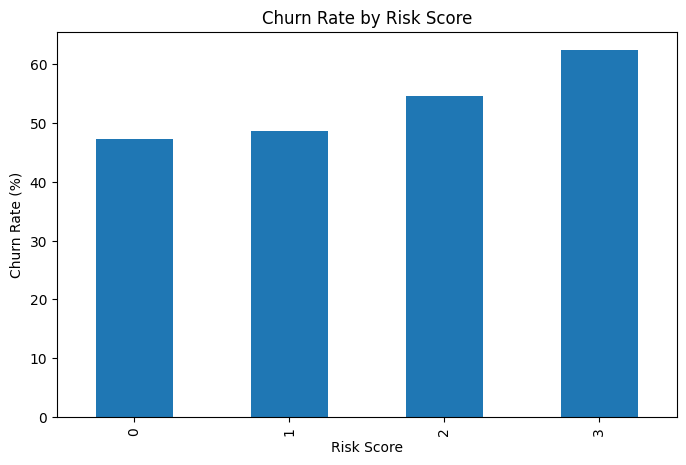

risk_score
0    47.28
1    48.63
2    54.60
3    62.43
Name: churn, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

risk_churn = (
    df.groupby('risk_score')['churn']
      .mean()
      .mul(100)
      .round(2)
)

plt.figure(figsize=(8,5))
risk_churn.plot(kind='bar')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Risk Score')
plt.title('Churn Rate by Risk Score')
plt.show()

print(risk_churn)

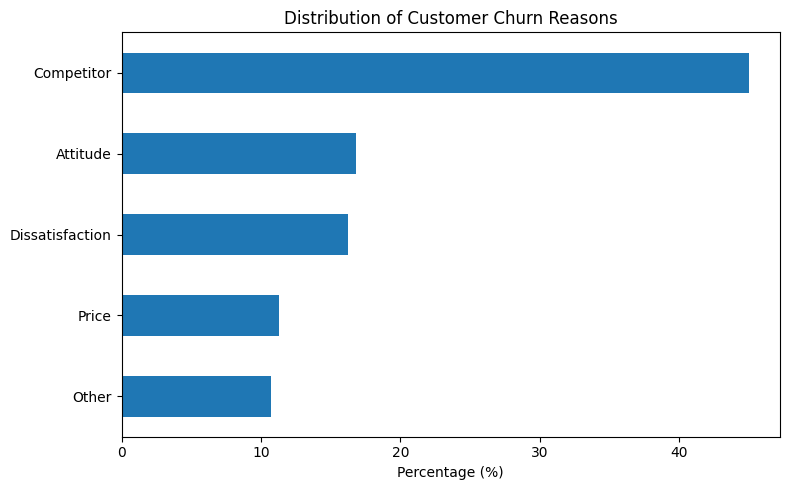

In [ ]:
import matplotlib.pyplot as plt

churn_category = (
    status_df['Churn Category']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(8,5))

churn_category.plot(
    kind='barh'
)

plt.title('Distribution of Customer Churn Reasons')
plt.xlabel('Percentage (%)')
plt.ylabel('')

plt.tight_layout()
plt.show()

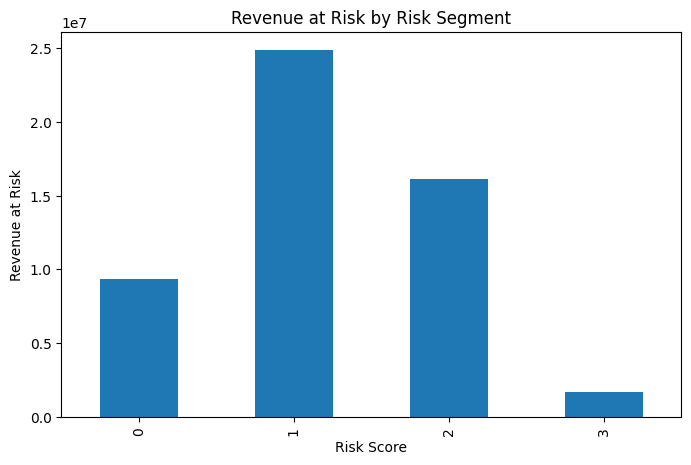

In [ ]:
import matplotlib.pyplot as plt

risk_summary['revenue_at_risk'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Revenue at Risk by Risk Segment')
plt.ylabel('Revenue at Risk')
plt.xlabel('Risk Score')
plt.show()

In [ ]:
alpha_segment = df[
    (df['device_age_group'] == '2+ Years') &
    (df['risk_score'] == 3)
]

print(alpha_segment.shape)

(1525, 113)


**ADDITIONAL DATASETS USED ARE:**

1. Telco_customer_churn_status.csv
2. Telco_customer_churn_services.csv

LINK :

1. https://www.kaggle.com/datasets/aadityabansalcodes/telecommunications-industry-customer-churn-dataset?select=Telco_customer_churn_status.csv              ---STATUS.CSV

2. https://www.kaggle.com/datasets/aadityabansalcodes/telecommunications-industry-customer-churn-dataset?select=Telco_customer_churn_services.csv            ---SERVICES.CSV

REMINDER !!!
THERE ARE 14 FILES BUT ONLY TWO FILES ARE USED: STATUS AND SERVICES (NO  OTHER FILES OTHER THAN THIS )


In [ ]:
#%cd "/content/drive/MyDrive/Additional Data"

#LINK TO ADDITIONAL DATASETS
#https://www.kaggle.com/datasets/aadityabansalcodes/telecommunications-industry-customer-churn-dataset?select=Telco_customer_churn_status.csv
#https://www.kaggle.com/datasets/aadityabansalcodes/telecommunications-industry-customer-churn-dataset?select=Telco_customer_churn_services.csv

%cd "/content/drive/MyDrive/Additional Data"

/content/drive/MyDrive/Additional Data


In [ ]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())

services_path = current_dir / "Telco_customer_churn_services.csv"
status_path = current_dir / "Telco_customer_churn_status.csv"

for p in (services_path, status_path):
    print(f"{'OK' if p.exists() else 'MISSING'} : {p}")

OK : /content/drive/MyDrive/Additional Data/Telco_customer_churn_services.csv
OK : /content/drive/MyDrive/Additional Data/Telco_customer_churn_status.csv


In [ ]:
import pandas as pd

services_df = pd.read_csv(services_path)
status_df = pd.read_csv(status_path)

print("Services Shape:", services_df.shape)
print("Status Shape:", status_df.shape)

Services Shape: (7043, 31)
Status Shape: (7043, 12)


In [ ]:
print("\nSERVICES COLUMNS\n")
print(services_df.columns.tolist())

print("\nSTATUS COLUMNS\n")
print(status_df.columns.tolist())


SERVICES COLUMNS

['Service ID', 'Customer ID', 'Count', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue']

STATUS COLUMNS

['Status ID', 'Customer ID', 'Count', 'Quarter', 'Satisfaction Score', 'Customer Status', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason']


In [ ]:
status_df.groupby('Satisfaction Score')['Churn Value']\
         .mean()\
         .mul(100)\
         .round(2)

,Churn Value
Satisfaction Score,
1,100.0
2,100.0
3,16.1
4,0.0
5,0.0


In [ ]:
status_df['cltv_group'] = pd.qcut(
    status_df['CLTV'],
    4,
    labels=['Low','Medium','High','Very High']
)

status_df.groupby('cltv_group')['Churn Value']\
         .mean()\
         .mul(100)\
         .round(2)

/tmp/ipykernel_4922/3942789906.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  status_df.groupby('cltv_group')['Churn Value']\


,Churn Value
cltv_group,
Low,34.43
Medium,26.83
High,24.15
Very High,20.73


In [ ]:
status_df['Churn Category']\
         .value_counts(normalize=True)\
         .mul(100)\
         .round(2)

,proportion
Churn Category,
Competitor,45.00
Attitude,16.80
Dissatisfaction,16.21
Price,11.29
Other,10.70


In [ ]:
status_df['Churn Reason']\
         .value_counts()\
         .head(10)

,count
Churn Reason,
Competitor had better devices,313
Competitor made better offer,311
Attitude of support person,220
Don't know,130
Competitor offered more data,117
Competitor offered higher download speeds,100
Attitude of service provider,94
Price too high,78
Product dissatisfaction,77


In [ ]:
ibm_df = services_df.merge(
    status_df,
    on='Customer ID',
    how='inner'
)

In [ ]:
ibm_df.groupby('Offer')['Churn Value']\
      .mean()\
      .mul(100)\
      .round(2)\
      .sort_values()

,Churn Value
Offer,
Offer A,6.73
Offer B,12.26
Offer C,22.89
Offer D,26.74
Offer E,52.92


In [ ]:
ibm_df.groupby('Premium Tech Support')['Churn Value']\
      .mean()\
      .mul(100)\
      .round(2)

,Churn Value
Premium Tech Support,
No,31.19
Yes,15.17


In [ ]:
ibm_df.groupby('Contract')['Churn Value']\
      .mean()\
      .mul(100)\
      .round(2)

,Churn Value
Contract,
Month-to-Month,45.84
One Year,10.71
Two Year,2.55


In [ ]:
contract_df = services_df.merge(
    status_df[['Customer ID', 'Churn Value']],
    on='Customer ID',
    how='inner'
)

contract_churn = (
    contract_df
    .groupby('Contract')['Churn Value']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(contract_churn)

Contract
Month-to-Month    45.844875
One Year          10.709677
Two Year           2.549124
Name: Churn Value, dtype: float64


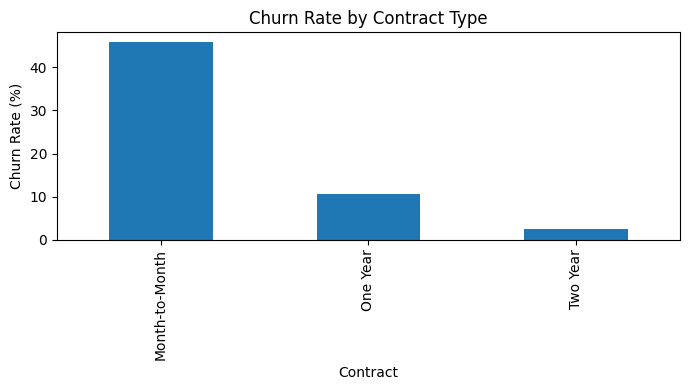

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

contract_churn.plot(kind='bar')

plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

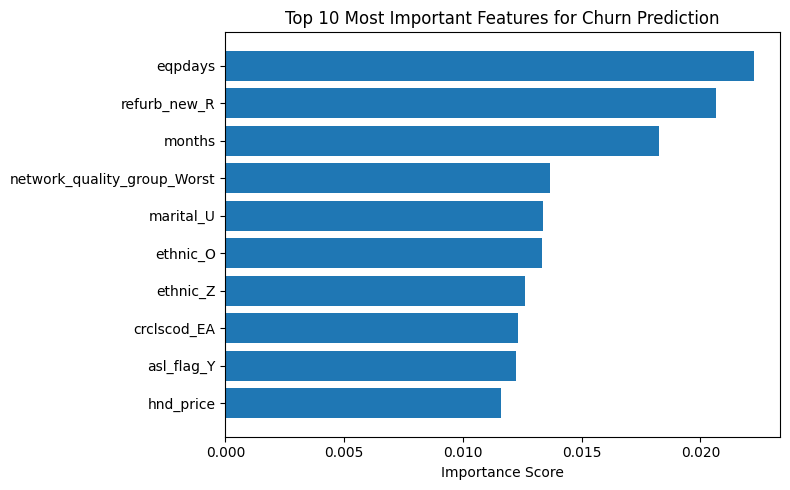

In [ ]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10['feature'][::-1],
    top10['importance'][::-1]
)

plt.title('Top 10 Most Important Features for Churn Prediction')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X2.columns,
    'importance': xgb2.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values('importance', ascending=False)
)

feature_importance.head(20)

,feature,importance
25,eqpdays,0.022237
157,refurb_new_R,0.020664
74,months,0.018262
207,network_quality_group_Worst,0.013662
163,marital_U,0.013386
174,ethnic_O,0.013325
180,ethnic_Z,0.012622
98,crclscod_EA,0.012322
131,asl_flag_Y,0.012244
17,hnd_price,0.011610


In [ ]:
support_df = services_df.merge(
    status_df[['Customer ID', 'Churn Value']],
    on='Customer ID',
    how='inner'
)

support_churn = (
    support_df
    .groupby('Premium Tech Support')['Churn Value']
    .mean()
    .mul(100)
)

print(support_churn)

Premium Tech Support
No     31.186237
Yes    15.166341
Name: Churn Value, dtype: float64


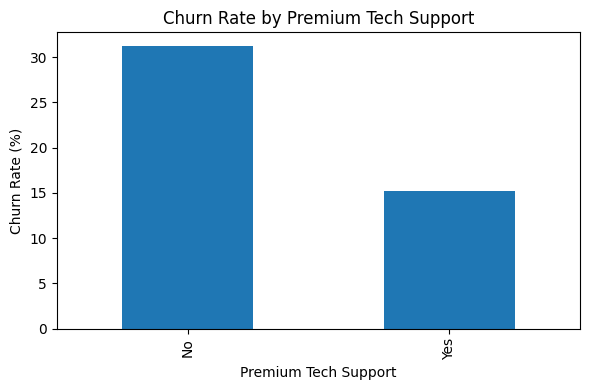

In [ ]:
plt.figure(figsize=(6,4))

support_churn.plot(kind='bar')

plt.title('Churn Rate by Premium Tech Support')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

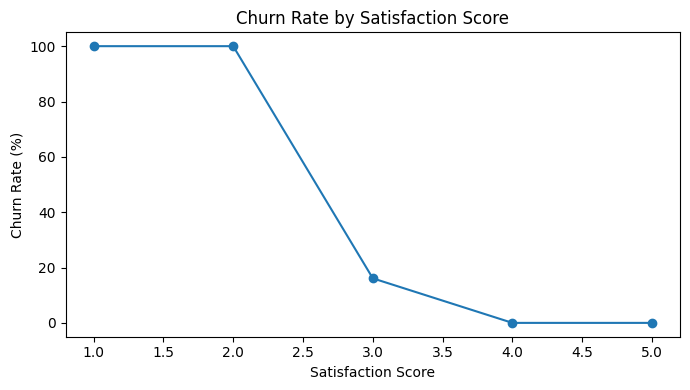

In [ ]:
sat_churn = (
    status_df
    .groupby('Satisfaction Score')['Churn Value']
    .mean()
    .mul(100)
)

plt.figure(figsize=(7,4))

sat_churn.plot(marker='o')

plt.title('Churn Rate by Satisfaction Score')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()